# Homework 1: Exploratory Data Analysis of NBA Games

**Student Name:** Nimrod Kritmaler
**Course:** Data Science  
**Lecturer:** Dr. Uri Itai

## 1. Project Objective

The purpose of this project is to perform an exploratory data analysis of NBA game data.

The analysis will examine the dataset structure, data types, missing values, potential biases, variable distributions, relationships between variables, and changes over time.

The dataset will be treated as the result of a data collection and measurement process rather than as an unquestionable representation of reality.

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

games_file_path = Path("data/games.csv")
games_df = pd.read_csv(games_file_path)

## 2. Dataset Selection and Source

### 2.1 Dataset Selection

The selected dataset contains historical NBA game-level data.

The dataset was chosen because it satisfies the assignment requirements:

- It is stored in a tabular format.
- It contains 26,651 rows.
- It contains 21 columns.
- It includes numerical variables, categorical variables, a binary outcome variable, and a game-date variable.

The subject was also selected because basketball is an area of personal interest. Familiarity with the game can help connect statistical findings to their practical basketball meaning while still maintaining a critical and data-driven approach.

### 2.2 Data Source

The dataset was downloaded from Kaggle and was published by Nathan Lauga under the title **NBA Games Data**.

According to the dataset description, the data was created using information obtained from the NBA statistics website. The complete Kaggle dataset contains five CSV files:

- `games.csv`
- `games_details.csv`
- `players.csv`
- `ranking.csv`
- `teams.csv`

This analysis focuses on `games.csv`, in which each row appears to represent a game together with its date, team identifiers, selected team-level statistics, and result. The uniqueness of the game records will be examined in the duplicate-data analysis.

### 2.3 Collection Purpose and Data Provider

The dataset publisher states that the data was collected for working with NBA game data, with game-winner prediction presented as one possible use.

The data appears to originate from an operational sports-information system rather than from a controlled academic study. The original NBA statistics system records game events and official box-score information as part of the league's regular reporting process.

However, the exact extraction procedure, validation rules, update schedule, and treatment of incomplete records are not fully documented in the CSV file itself. This missing documentation is an important limitation and will be considered throughout the analysis.

### 2.4 Domain Context

Each row appears to represent one NBA game.

The dataset separates the statistics of the home team and the away team. For example:

- `PTS_home` and `PTS_away` represent points scored.
- `FG_PCT_home` and `FG_PCT_away` represent field-goal percentages.
- `FT_PCT_home` and `FT_PCT_away` represent free-throw percentages.
- `FG3_PCT_home` and `FG3_PCT_away` represent three-point percentages.
- `AST_home` and `AST_away` represent assists.
- `REB_home` and `REB_away` represent rebounds.
- `HOME_TEAM_WINS` indicates whether the home team won.

These variables allow the analysis to examine both basketball performance and broader questions such as home-court advantage, differences between winning and losing teams, and changes across seasons.

## 3. Dataset Meta-Analysis

This section provides an initial examination of the dataset file and its internal structure.

The analysis includes the file format, file size, dataset dimensions, column names, data types, missing-value counts, and the number of unique values in each column.

In [2]:
file_size_mb = games_file_path.stat().st_size / (1024 ** 2)

column_summary_df = pd.DataFrame({
    "Data Type": games_df.dtypes.astype(str),
    "Non-Null Values": games_df.notna().sum(),
    "Missing Values": games_df.isna().sum(),
    "Unique Values": games_df.nunique(dropna=False)
})

print("FILE INFORMATION")
print("-" * 50)
print(f"File name: {games_file_path.name}")
print(f"File format: {games_file_path.suffix}")
print(f"File size: {file_size_mb:.2f} MB")

print("\nDATASET DIMENSIONS")
print("-" * 50)
print(f"Number of rows: {games_df.shape[0]:,}")
print(f"Number of columns: {games_df.shape[1]}")

print("\nCOLUMN SUMMARY")
display(column_summary_df)

FILE INFORMATION
--------------------------------------------------
File name: games.csv
File format: .csv
File size: 3.92 MB

DATASET DIMENSIONS
--------------------------------------------------
Number of rows: 26,651
Number of columns: 21

COLUMN SUMMARY


,Data Type,Non-Null Values,Missing Values,Unique Values
GAME_DATE_EST,str,26651,0,4304
GAME_ID,int64,26651,0,26622
GAME_STATUS_TEXT,str,26651,0,1
HOME_TEAM_ID,int64,26651,0,30
VISITOR_TEAM_ID,int64,26651,0,30
SEASON,int64,26651,0,20
TEAM_ID_home,int64,26651,0,30
PTS_home,float64,26552,99,101
FG_PCT_home,float64,26552,99,405
FT_PCT_home,float64,26552,99,411


### 3.1 File Analysis

The analyzed file is named `games.csv`. It is stored in CSV format and has a local file size of approximately 3.92 MB.

The exact original creation date of the dataset is not documented in the CSV file or in the available metadata. Therefore, the local file modification date is not used, since it mainly reflects when the file was downloaded, copied, or modified on the current computer rather than when the dataset was originally created.

The file contains historical NBA game-level data. Its apparent purpose is to organize game information for reporting and analysis, including game dates, team identifiers, seasons, selected team-level statistics, and game outcomes.

The lack of a documented creation date, version number, and detailed update history is a metadata limitation. It makes it difficult to determine precisely when the dataset was first assembled, how it changed over time, and whether the downloaded file represents the latest available version.

### 3.2 Dataset Structure

The dataset contains 26,651 rows and 21 columns.

Based on its structure, each row appears to represent one NBA game. This assumption will later be verified by examining the uniqueness of `GAME_ID`.

The column names are generally meaningful and follow a consistent naming convention. Home-team variables use the suffix `_home`, while away-team variables use the suffix `_away`. Examples include `PTS_home`, `PTS_away`, `AST_home`, and `AST_away`.

The dataset contains 12 columns stored as floating-point values, 7 columns stored as integers, and 2 columns stored as strings.

The storage type does not always represent the analytical meaning of a variable. For example, `GAME_ID` and the team ID columns are stored as integers, but they represent identifiers rather than measurable numerical quantities.

The main variable types are:

- Numerical game statistics, such as points, shooting percentages, assists, and rebounds
- Identifier variables for games and teams
- A binary outcome variable, `HOME_TEAM_WINS`
- A time-related variable, `GAME_DATE_EST`
- A categorical variable, `GAME_STATUS_TEXT`
- A discrete season variable, `SEASON`

The `GAME_DATE_EST` column was loaded as a string and will need to be converted to a datetime variable before time-based analysis.

The dataset appears to contain operational sports data rather than data collected specifically for a controlled research study. It was likely created from game-reporting and record-keeping systems.

Possible biases and limitations include missing contextual factors such as injuries, player availability, rest days, travel, coaching changes, and game importance. The exact collection and validation procedures are also not fully documented.

## 4. Data Quality and Completeness

This section examines missing values, duplicate records, suspicious values, and feature cardinality.

The goal is not to remove problematic values automatically, but to understand whether they reflect data-entry errors, collection limitations, or meaningful characteristics of the dataset.

### 4.1 Missing Values

The first step is to measure the extent of missing data and examine whether the missing values occur independently or follow a structured pattern.

In [3]:
missing_summary_df = pd.DataFrame({
    "Missing Count": games_df.isna().sum(),
    "Missing Percentage": games_df.isna().mean() * 100
})

missing_summary_df = missing_summary_df[
    missing_summary_df["Missing Count"] > 0
].sort_values("Missing Count", ascending=False)

print("MISSING VALUES SUMMARY")
display(missing_summary_df)

rows_with_missing_values = games_df[games_df.isna().any(axis=1)]

print(f"Rows containing at least one missing value: {len(rows_with_missing_values):,}")
print(
    f"Percentage of rows containing missing values: "
    f"{len(rows_with_missing_values) / len(games_df) * 100:.2f}%"
)


MISSING VALUES SUMMARY


,Missing Count,Missing Percentage
PTS_home,99,0.371468
FG_PCT_home,99,0.371468
FT_PCT_home,99,0.371468
FG3_PCT_home,99,0.371468
AST_home,99,0.371468
REB_home,99,0.371468
PTS_away,99,0.371468
FG_PCT_away,99,0.371468
FT_PCT_away,99,0.371468
FG3_PCT_away,99,0.371468


Rows containing at least one missing value: 99
Percentage of rows containing missing values: 0.37%


In [4]:
statistical_columns = [
    "PTS_home",
    "FG_PCT_home",
    "FT_PCT_home",
    "FG3_PCT_home",
    "AST_home",
    "REB_home",
    "PTS_away",
    "FG_PCT_away",
    "FT_PCT_away",
    "FG3_PCT_away",
    "AST_away",
    "REB_away"
]

missing_pattern_df = games_df[statistical_columns].isna()
print("MISSINGNESS PATTERNS")

display(
    missing_pattern_df
    .value_counts()
    .reset_index(name="Row Count")
)


MISSINGNESS PATTERNS


,PTS_home,FG_PCT_home,FT_PCT_home,FG3_PCT_home,AST_home,REB_home,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,Row Count
0,False,False,False,False,False,False,False,False,False,False,False,False,26552
1,True,True,True,True,True,True,True,True,True,True,True,True,99


In [5]:
missing_rows_summary = (
    rows_with_missing_values
    .groupby(["SEASON", "GAME_DATE_EST"])
    .size()
    .reset_index(name="Missing Games")
    .sort_values(["SEASON", "GAME_DATE_EST"])
)

display(missing_rows_summary)

print("Seasons with missing game statistics:")
print(
    rows_with_missing_values["SEASON"]
    .value_counts()
    .sort_index()
)

print("\nDate range of rows with missing values:")
print(rows_with_missing_values["GAME_DATE_EST"].min())
print(rows_with_missing_values["GAME_DATE_EST"].max())

,SEASON,GAME_DATE_EST,Missing Games
0,2003,2003-10-07,1
1,2003,2003-10-08,2
2,2003,2003-10-09,4
3,2003,2003-10-10,5
4,2003,2003-10-11,9
5,2003,2003-10-12,3
6,2003,2003-10-13,2
7,2003,2003-10-14,10
8,2003,2003-10-15,4
9,2003,2003-10-16,6


Seasons with missing game statistics:
SEASON
2003    99
Name: count, dtype: int64

Date range of rows with missing values:
2003-10-07
2003-10-24


#### Missing-Value Findings

The dataset contains 99 rows with missing values, representing approximately 0.37% of all records.

The missing values occur in all 12 home-team and away-team statistical columns at the same time. No partial missingness was found within these columns.

All affected records belong to the 2003 season and fall between October 7, 2003, and October 24, 2003.

This pattern indicates structured missingness rather than isolated random missing values. The missingness is likely related to a specific period, game category, or limitation in the historical data-collection process.

Because all box-score statistics are missing together, imputing individual values using a mean or median would create artificial game records and may distort the analysis. A more appropriate approach would be to exclude these 99 rows only from analyses that require the missing statistical variables, while retaining them for analyses based on dates, teams, seasons, or game outcomes.

No rows are removed at this stage.

### 4.2 Duplicate Records

This section examines both full-row duplicates and partial duplicates based on important identifying columns.

The goal is to determine whether repeated records represent data-quality problems, repeated observations, or meaningful differences between apparently similar games.

In [6]:
# Check for full-row duplicates
full_duplicate_count = games_df.duplicated().sum()

# Identify all rows whose GAME_ID appears more than once
duplicate_game_id_mask = games_df.duplicated(
    subset=["GAME_ID"],
    keep=False
)

duplicate_game_id_rows = (
    games_df[duplicate_game_id_mask]
    .sort_values(["GAME_ID", "GAME_DATE_EST"])
)

print("FULL-ROW DUPLICATES")
print("-" * 50)
print(f"Number of full-row duplicates: {full_duplicate_count:,}")

print("\nDUPLICATE GAME IDENTIFIERS")
print("-" * 50)
print(
    f"Rows with a duplicated GAME_ID: "
    f"{len(duplicate_game_id_rows):,}"
)
print(
    f"Duplicated GAME_ID values: "
    f"{duplicate_game_id_rows['GAME_ID'].nunique():,}"
)

FULL-ROW DUPLICATES
--------------------------------------------------
Number of full-row duplicates: 0

DUPLICATE GAME IDENTIFIERS
--------------------------------------------------
Rows with a duplicated GAME_ID: 58
Duplicated GAME_ID values: 29


In [7]:
# Compare duplicated records while ignoring negligible floating-point differences
duplicate_classification = []
conflict_details = []

for game_id, game_group in duplicate_game_id_rows.groupby("GAME_ID"):
    game_group = game_group.reset_index(drop=True)

    first_record = game_group.iloc[0]
    second_record = game_group.iloc[1]
    meaningful_columns = []

    for column_name in games_df.columns:
        if column_name == "GAME_ID":
            continue

        first_value = first_record[column_name]
        second_value = second_record[column_name]

        both_missing = pd.isna(first_value) and pd.isna(second_value)
        one_missing = pd.isna(first_value) != pd.isna(second_value)

        if both_missing:
            values_match = True
            absolute_difference = None

        elif one_missing:
            values_match = False
            absolute_difference = None

        elif pd.api.types.is_numeric_dtype(games_df[column_name]):
            absolute_difference = abs(
                float(first_value) - float(second_value)
            )
            values_match = absolute_difference <= 1e-9

        else:
            absolute_difference = None
            values_match = first_value == second_value

        if not values_match:
            meaningful_columns.append(column_name)

            conflict_details.append({
                "GAME_ID": game_id,
                "Column": column_name,
                "First Value": first_value,
                "Second Value": second_value,
                "Absolute Difference": absolute_difference
            })

    duplicate_classification.append({
        "GAME_ID": game_id,
        "Has Meaningful Difference": len(meaningful_columns) > 0
    })

duplicate_classification_df = pd.DataFrame(
    duplicate_classification
)

conflict_details_df = pd.DataFrame(conflict_details)

near_identical_duplicate_count = (
    ~duplicate_classification_df["Has Meaningful Difference"]
).sum()

conflicting_duplicate_count = (
    duplicate_classification_df["Has Meaningful Difference"]
).sum()

print("DUPLICATE RECORD CLASSIFICATION")
print("-" * 50)
print(
    f"Near-identical duplicated GAME_ID values: "
    f"{near_identical_duplicate_count}"
)
print(
    f"Duplicated GAME_ID values with meaningful differences: "
    f"{conflicting_duplicate_count}"
)

print("\nMEANINGFUL CONFLICTS")
display(conflict_details_df)

DUPLICATE RECORD CLASSIFICATION
--------------------------------------------------
Near-identical duplicated GAME_ID values: 27
Duplicated GAME_ID values with meaningful differences: 2

MEANINGFUL CONFLICTS


,GAME_ID,Column,First Value,Second Value,Absolute Difference
0,22000070,REB_away,45.000,44.000,1.000
1,22000076,FG_PCT_home,0.459,0.453,0.006


#### Duplicate Findings

No full-row duplicates were found in the dataset.

However, 29 `GAME_ID` values appear twice, affecting 58 rows in total.

For 27 of these game identifiers, the apparent differences are approximately \(10^{-16}\). These are negligible floating-point representation differences rather than meaningful differences in the underlying basketball statistics. Therefore, these records can be treated as near-identical duplicates.

Two duplicated game identifiers contain meaningful conflicts:

- Game `22000076` contains a difference of `0.006` in `FG_PCT_home`.
- Game `22000070` contains a difference of one rebound in `REB_away`.

The near-identical duplicates may later be reduced to one row per game. However, the two conflicting pairs should not be resolved arbitrarily because the dataset does not indicate which version is correct.

A cautious approach is to preserve the raw dataset and flag the conflicting records before analyses that depend on the affected variables.

### 4.3 Suspicious Values

This section examines values that may be impossible, implausible, or used as placeholders.

The checks are based on the expected meaning of each variable. Shooting percentages should fall between 0 and 1, game statistics should not be negative, identifiers should be positive, and the binary outcome should contain only the values 0 and 1.

In [8]:
game_stat_columns = [
    "PTS_home", "FG_PCT_home", "FT_PCT_home", "FG3_PCT_home",
    "AST_home", "REB_home",
    "PTS_away", "FG_PCT_away", "FT_PCT_away", "FG3_PCT_away",
    "AST_away", "REB_away"
]

percentage_columns = [
    "FG_PCT_home", "FT_PCT_home", "FG3_PCT_home",
    "FG_PCT_away", "FT_PCT_away", "FG3_PCT_away"
]

placeholder_values = [-9999, -999, -99, 999, 9999]

suspicious_values_df = pd.DataFrame({
    "Minimum": games_df[game_stat_columns].min(),
    "Maximum": games_df[game_stat_columns].max(),
    "Negative Values": games_df[game_stat_columns].lt(0).sum(),
    "Zero Values": games_df[game_stat_columns].eq(0).sum(),
    "Placeholder Values": games_df[game_stat_columns]
        .isin(placeholder_values)
        .sum()
})

display(suspicious_values_df)

print("Percentage values outside the valid range [0, 1]:")
display(
    (
        games_df[percentage_columns].lt(0)
        | games_df[percentage_columns].gt(1)
    ).sum().to_frame(name="Invalid Values")
)

print("HOME_TEAM_WINS values:")
display(
    games_df["HOME_TEAM_WINS"]
    .value_counts(dropna=False)
    .sort_index()
    .to_frame(name="Count")
)

,Minimum,Maximum,Negative Values,Zero Values,Placeholder Values
PTS_home,36.000,168.000,0,0,0
FG_PCT_home,0.250,0.684,0,0,0
FT_PCT_home,0.143,1.000,0,0,0
FG3_PCT_home,0.000,1.000,0,106,0
AST_home,6.000,50.000,0,0,0
REB_home,15.000,72.000,0,0,0
PTS_away,33.000,168.000,0,0,0
FG_PCT_away,0.244,0.687,0,0,0
FT_PCT_away,0.143,1.000,0,0,0
FG3_PCT_away,0.000,1.000,0,118,0


Percentage values outside the valid range [0, 1]:


,Invalid Values
FG_PCT_home,0
FT_PCT_home,0
FG3_PCT_home,0
FG_PCT_away,0
FT_PCT_away,0
FG3_PCT_away,0


HOME_TEAM_WINS values:


,Count
HOME_TEAM_WINS,
0,11006
1,15645


#### Suspicious-Value Findings

No negative values were found in the numerical game-statistic columns.

All shooting-percentage values fall within the valid range of 0 to 1. Values of `1.0` represent a 100% shooting percentage and are therefore possible, although they may be based on a small number of attempts.

No common placeholder codes from the tested list were found in the game-statistic columns.

Zero values appear only in the three-point percentage columns:

- `FG3_PCT_home` contains 106 zero values.
- `FG3_PCT_away` contains 118 zero values.

A zero three-point percentage may be a valid basketball result, meaning that the team did not make any three-point shots. However, because the dataset does not include the number of three-point attempts, it is not possible to distinguish between a team that missed all attempts and a team that made no attempts.

The `HOME_TEAM_WINS` variable contains only the values `0` and `1`, which is consistent with its expected binary meaning.

Some minimum and maximum values, such as very low game scores or unusually high rebound and assist totals, appear extreme but are not impossible. 

### 4.4 Cardinality

This section examines the number of unique values in each column.

Low-cardinality columns may contain little or no variation, while high-cardinality columns may represent identifiers or variables that require careful interpretation.

In [9]:
cardinality_summary_df = pd.DataFrame({
    "Data Type": games_df.dtypes.astype(str),
    "Unique Values": games_df.nunique(dropna=False),
    "Unique Percentage": (
        games_df.nunique(dropna=False) / len(games_df) * 100
    )
}).sort_values(
    "Unique Values",
    ascending=False
)

constant_columns = cardinality_summary_df[
    cardinality_summary_df["Unique Values"] == 1
]

print("CARDINALITY SUMMARY")
display(cardinality_summary_df)

print("CONSTANT COLUMNS")
display(constant_columns)

CARDINALITY SUMMARY


,Data Type,Unique Values,Unique Percentage
GAME_ID,int64,26622,99.891186
GAME_DATE_EST,str,4304,16.149488
FG3_PCT_home,float64,438,1.643466
FG3_PCT_away,float64,418,1.568421
FT_PCT_home,float64,411,1.542156
FG_PCT_home,float64,405,1.519643
FG_PCT_away,float64,394,1.478369
FT_PCT_away,float64,388,1.455855
PTS_away,float64,107,0.401486
PTS_home,float64,101,0.378973


CONSTANT COLUMNS


,Data Type,Unique Values,Unique Percentage
GAME_STATUS_TEXT,str,1,0.003752


#### Cardinality Findings

The cardinality analysis identified one constant column: `GAME_STATUS_TEXT`.

`GAME_STATUS_TEXT` contains only one unique value across all 26,651 rows. Therefore, it provides no variation in the current dataset and cannot support comparisons or statistical relationships.

`GAME_ID` has 26,622 unique values, representing approximately 99.89% of the rows. This confirms that it functions primarily as an identifier. The difference between the number of rows and the number of unique game IDs is consistent with the 29 duplicated identifiers found in the duplicate analysis.

`GAME_DATE_EST` contains 4,304 unique values, representing approximately 16.15% of the dataset. Its relatively high cardinality is meaningful because multiple NBA games can occur on the same date, while the variation across dates supports temporal analysis.

Each team identifier column contains 30 unique values:

- `HOME_TEAM_ID`
- `VISITOR_TEAM_ID`
- `TEAM_ID_home`
- `TEAM_ID_away`

This is consistent with categorical variables representing NBA teams. However, identical cardinality alone does not prove that the corresponding identifier columns contain exactly the same values.

`SEASON` contains 20 unique values, representing the seasons covered by the dataset.

`HOME_TEAM_WINS` contains two unique values, which is consistent with its binary meaning.

The numerical game-statistic columns have moderate cardinality. For example, the points columns contain 101 and 107 unique values, while the shooting-percentage columns contain between 388 and 438 unique values. This reflects the different measurement scales of discrete game counts and rounded percentage values.

The constant `GAME_STATUS_TEXT` column should remain in the raw dataset for documentation purposes, but it does not contribute analytical variation.

## 5. Univariate Analysis

### 5.1 Numerical Variables

This section examines each numerical game-statistic variable separately.

The analysis includes measures of central tendency, variability, robust statistics, distribution shape, and one-dimensional outlier detection.

In [10]:
numeric_game_columns = [
    "PTS_home",
    "FG_PCT_home",
    "FT_PCT_home",
    "FG3_PCT_home",
    "AST_home",
    "REB_home",
    "PTS_away",
    "FG_PCT_away",
    "FT_PCT_away",
    "FG3_PCT_away",
    "AST_away",
    "REB_away"
]

first_quartile = games_df[numeric_game_columns].quantile(0.25)
third_quartile = games_df[numeric_game_columns].quantile(0.75)

numerical_summary_df = pd.DataFrame({
    "Count": games_df[numeric_game_columns].count(),
    "Mean": games_df[numeric_game_columns].mean(),
    "Median": games_df[numeric_game_columns].median(),
    "Standard Deviation": games_df[numeric_game_columns].std(),
    "MAD": games_df[numeric_game_columns].apply(
        lambda column: (column - column.median()).abs().median()
    ),
    "Minimum": games_df[numeric_game_columns].min(),
    "Q1": first_quartile,
    "Q3": third_quartile,
    "Maximum": games_df[numeric_game_columns].max(),
    "IQR": third_quartile - first_quartile,
    "Skewness": games_df[numeric_game_columns].skew()
}).round(3)

display(numerical_summary_df)

,Count,Mean,Median,Standard Deviation,MAD,Minimum,Q1,Q3,Maximum,IQR,Skewness
PTS_home,26552,103.456,103.000,13.283,9.000,36.000,94.000,112.000,168.000,18.000,0.173
FG_PCT_home,26552,0.461,0.460,0.057,0.040,0.250,0.422,0.500,0.684,0.078,0.096
FT_PCT_home,26552,0.760,0.765,0.101,0.068,0.143,0.697,0.833,1.000,0.136,-0.380
FG3_PCT_home,26552,0.356,0.357,0.111,0.071,0.000,0.286,0.429,1.000,0.143,0.060
AST_home,26552,22.823,23.000,5.193,4.000,6.000,19.000,26.000,50.000,7.000,0.248
REB_home,26552,43.374,43.000,6.626,4.000,15.000,39.000,48.000,72.000,9.000,0.184
PTS_away,26552,100.640,100.000,13.436,9.000,33.000,91.000,110.000,168.000,19.000,0.187
FG_PCT_away,26552,0.450,0.449,0.056,0.038,0.244,0.412,0.487,0.687,0.075,0.082
FT_PCT_away,26552,0.759,0.765,0.103,0.068,0.143,0.692,0.833,1.000,0.141,-0.372
FG3_PCT_away,26552,0.349,0.350,0.109,0.071,0.000,0.278,0.419,1.000,0.141,0.088


#### Numerical Summary Findings

All numerical game-statistic columns contain 26,552 valid observations, which is consistent with the 99 missing game records identified earlier.

For most variables, the mean and median are relatively close. This suggests that their central values are not strongly affected by asymmetry.

The points distributions are slightly right-skewed:

- `PTS_home` has a skewness of 0.173.
- `PTS_away` has a skewness of 0.187.

The field-goal and three-point percentage distributions are close to symmetric, with skewness values near zero.

The free-throw percentage variables show the clearest asymmetry:

- `FT_PCT_home` has a skewness of -0.380.
- `FT_PCT_away` has a skewness of -0.372.

This indicates moderate left skew, meaning that most free-throw percentages are concentrated toward higher values, with a longer tail toward lower percentages.

Assists and rebounds show mild positive skewness. However, none of the variables show extreme skewness based on the summary statistics alone.

The home-team averages are moderately higher than the away-team averages for points, field-goal percentage, three-point percentage, assists, and rebounds. Free-throw percentages are nearly identical. These differences are descriptive and do not by themselves establish statistical significance or causation.

The MAD provides a robust measure of spread because it is based on distances from the median and is less sensitive to extreme observations than the standard deviation. The raw MAD and standard deviation should not be compared directly as equivalent measures because they are defined on different scales.

#### One-Dimensional Outlier Detection

Outliers are examined using the three methods presented in the course:

1. Values located more than three standard deviations from the mean.
2. Values located more than three MAD units from the median.
3. Values outside the interval defined by 1.5 times the IQR below Q1 or above Q3.

The methods may identify different numbers of observations because they use different measures of center and spread.

In [11]:
outlier_results = []

for column_name in numeric_game_columns:
    values = games_df[column_name].dropna()

    mean_value = values.mean()
    standard_deviation = values.std()

    median_value = values.median()
    mad_value = (values - median_value).abs().median()

    first_quartile = values.quantile(0.25)
    third_quartile = values.quantile(0.75)
    iqr_value = third_quartile - first_quartile

    std_outliers = (
        (values < mean_value - 3 * standard_deviation)
        | (values > mean_value + 3 * standard_deviation)
    ).sum()

    mad_outliers = (
        (values < median_value - 3 * mad_value)
        | (values > median_value + 3 * mad_value)
    ).sum()

    iqr_outliers = (
        (values < first_quartile - 1.5 * iqr_value)
        | (values > third_quartile + 1.5 * iqr_value)
    ).sum()

    outlier_results.append({
        "Column": column_name,
        "3 STD Count": std_outliers,
        "3 STD Percentage": std_outliers / len(values) * 100,
        "3 MAD Count": mad_outliers,
        "3 MAD Percentage": mad_outliers / len(values) * 100,
        "1.5 IQR Count": iqr_outliers,
        "1.5 IQR Percentage": iqr_outliers / len(values) * 100
    })

outlier_summary_df = (
    pd.DataFrame(outlier_results)
    .set_index("Column")
    .round(3)
)

display(outlier_summary_df)

,3 STD Count,3 STD Percentage,3 MAD Count,3 MAD Percentage,1.5 IQR Count,1.5 IQR Percentage
Column,,,,,,
PTS_home,82,0.309,1019,3.838,207,0.780
FG_PCT_home,68,0.256,862,3.246,153,0.576
FT_PCT_home,129,0.486,1144,4.309,209,0.787
FG3_PCT_home,189,0.712,1684,6.342,381,1.435
AST_home,87,0.328,415,1.563,215,0.810
REB_home,82,0.309,1536,5.785,201,0.757
PTS_away,92,0.346,1088,4.098,134,0.505
FG_PCT_away,74,0.279,1065,4.011,197,0.742
FT_PCT_away,126,0.475,1268,4.776,250,0.942


#### Outlier Detection Findings

All three methods identified outliers in every numerical game-statistic variable, but the number of detected observations differs substantially between the methods.

The three-standard-deviation method is the most conservative in this dataset. It classified between 0.256% and 0.731% of the valid observations as outliers.

The 1.5 IQR method produced intermediate results, identifying between 0.505% and 1.435% of the observations as outliers.

The three-MAD method is the most sensitive method in this analysis. It identified between 1.563% and 6.613% of the observations as outliers. The highest percentages were found in `AST_away`, `FG3_PCT_home`, `REB_home`, and `REB_away`.

The three-point percentage variables contain relatively high outlier percentages under all three methods. This suggests that their distributions include more extreme low or high values relative to their typical range.

The difference between the methods demonstrates that outlier detection depends on the selected definition of center and spread. Statistical outliers in this dataset are not necessarily data errors; they may represent genuine games with unusually high or low team performance.

Therefore, no observations are removed solely because they were classified as outliers by one of these methods.

### 5.2 Categorical Variables

This section examines the frequency distributions of the selected categorical variables.

For each variable, the analysis identifies:

- The most frequent category and its percentage.
- The five most frequent categories and their combined coverage.
- The minimum number of categories required to cover 80% of the observations.
- The specific categories included in that 80% coverage.
- Categories representing less than 1% of the observations.

`GAME_ID` is excluded because it is an identifier rather than a meaningful category for frequency analysis. `GAME_STATUS_TEXT` is also excluded because it was already identified as a constant column.

In [12]:
categorical_columns = [
    "HOME_TEAM_ID",
    "VISITOR_TEAM_ID",
    "SEASON",
    "HOME_TEAM_WINS"
]

top_k = 5
coverage_target = 0.80
rare_threshold = 0.01

categorical_summary_rows = []
top_category_rows = []
coverage_value_rows = []

for column_name in categorical_columns:
    counts = games_df[column_name].value_counts(dropna=False)
    proportions = games_df[column_name].value_counts(
        normalize=True,
        dropna=False
    )

    cumulative_proportions = proportions.cumsum()

    categories_needed = (
        cumulative_proportions < coverage_target
    ).sum() + 1

    values_covering_80_percent = (
        counts.index[:categories_needed].tolist()
    )

    rare_categories = (
        proportions[proportions < rare_threshold]
        .index
        .tolist()
    )

    categorical_summary_rows.append({
        "Variable": column_name,
        "Unique Categories": counts.size,
        "Mode": counts.index[0],
        "Mode Percentage": proportions.iloc[0] * 100,
        "Top 5 Coverage": proportions.head(top_k).sum() * 100,
        "Categories for 80% Coverage": categories_needed,
        "Rare Categories Below 1%": len(rare_categories)
    })

    coverage_value_rows.append({
        "Variable": column_name,
        "Values Covering 80%": ", ".join(
            map(str, values_covering_80_percent)
        )
    })

    for category_value, category_count in counts.head(top_k).items():
        top_category_rows.append({
            "Variable": column_name,
            "Category": category_value,
            "Count": category_count,
            "Percentage": proportions.loc[category_value] * 100
        })

categorical_summary_df = (
    pd.DataFrame(categorical_summary_rows)
    .set_index("Variable")
    .round(2)
)

top_categories_df = (
    pd.DataFrame(top_category_rows)
    .set_index(["Variable", "Category"])
    .round(2)
)

coverage_values_df = (
    pd.DataFrame(coverage_value_rows)
    .set_index("Variable")
)

print("CATEGORICAL SUMMARY")
display(categorical_summary_df)

print("TOP FIVE CATEGORIES")
display(top_categories_df)

print("VALUES REQUIRED FOR 80% COVERAGE")
display(coverage_values_df)

CATEGORICAL SUMMARY


,Unique Categories,Mode,Mode Percentage,Top 5 Coverage,Categories for 80% Coverage,Rare Categories Below 1%
Variable,,,,,,
HOME_TEAM_ID,30,1610612747,3.64,17.79,24,0
VISITOR_TEAM_ID,30,1610612748,3.52,17.43,24,0
SEASON,20,2005,5.37,26.75,16,0
HOME_TEAM_WINS,2,1,58.70,100.00,2,0


TOP FIVE CATEGORIES


Count  Percentage
Variable        Category                     
HOME_TEAM_ID    1610612747    969        3.64
                1610612748    959        3.60
                1610612738    950        3.56
                1610612759    942        3.53
                1610612739    921        3.46
VISITOR_TEAM_ID 1610612748    939        3.52
                1610612738    938        3.52
                1610612759    931        3.49
                1610612743    920        3.45
                1610612744    916        3.44
SEASON          2005         1432        5.37
                2013         1427        5.35
                2008         1425        5.35
                2009         1424        5.34
                2010         1422        5.34
HOME_TEAM_WINS  1           15645       58.70
                0           11006       41.30

VALUES REQUIRED FOR 80% COVERAGE


,Values Covering 80%
Variable,
HOME_TEAM_ID,"1610612747, 1610612748, 1610612738, 1610612759..."
VISITOR_TEAM_ID,"1610612748, 1610612738, 1610612759, 1610612743..."
SEASON,"2005, 2013, 2008, 2009, 2010, 2012, 2006, 2014..."
HOME_TEAM_WINS,"1, 0"


#### Categorical-Variable Findings

The home-team and visitor-team identifier columns each contain 30 unique categories.

The most frequent home-team identifier represents 3.64% of the games, while the most frequent visitor-team identifier represents 3.52%. The five most frequent team identifiers cover only a relatively small part of the dataset.

For both team-identifier variables, 24 of the 30 categories are required to cover 80% of the observations. The specific identifiers included in this coverage are shown in the coverage table.

This indicates that the observations are distributed relatively evenly across the team identifiers, with no single identifier dominating the dataset. However, the identifiers cannot be interpreted as specific teams without an additional team-mapping table.

The dataset contains 20 seasons. The most frequent season is 2005 and represents 5.37% of the observations. Sixteen seasons are required to cover 80% of the dataset, indicating that the records are distributed across many seasons rather than concentrated in only a few.

`HOME_TEAM_WINS` contains two categories. Home-team wins are the mode and represent 58.70% of the games, while away-team wins represent 41.30%.

No analyzed categorical variable contains a category representing less than 1% of the observations. Therefore, no rare categories were identified using the selected threshold.

There is no statistical reason to merge categories based only on frequency. In particular, team identifiers represent distinct teams and should not be combined merely because some appear less frequently than others.

The mode alone does not represent the team or season variables particularly well because the most frequent category covers only a small percentage of the observations. It is more informative for `HOME_TEAM_WINS`, although the minority category still represents a substantial 41.30% of the games.

## 6. Correlations and Relationships

### 6.1 Numerical–Numerical Relationships

Three correlation methods are used:

- Pearson correlation measures linear relationships between numerical variables.
- Spearman correlation measures monotonic relationships using ranks.
- Kendall correlation measures ordinal association based on concordant and discordant pairs.

Comparing the three methods helps identify whether relationships are mainly linear or whether they remain consistent only in rank or direction.

In [13]:
pearson_correlation_df = (
    games_df[numeric_game_columns]
    .corr(method="pearson")
    .round(3)
)

spearman_correlation_df = (
    games_df[numeric_game_columns]
    .corr(method="spearman")
    .round(3)
)

kendall_correlation_df = (
    games_df[numeric_game_columns]
    .corr(method="kendall")
    .round(3)
)

print("PEARSON CORRELATION")
display(pearson_correlation_df)

print("SPEARMAN CORRELATION")
display(spearman_correlation_df)

print("KENDALL CORRELATION")
display(kendall_correlation_df)

PEARSON CORRELATION


,PTS_home,FG_PCT_home,FT_PCT_home,FG3_PCT_home,AST_home,REB_home,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away
PTS_home,1.000,0.662,0.187,0.422,0.605,0.162,0.488,0.132,0.072,0.057,0.216,-0.141
FG_PCT_home,0.662,1.000,0.021,0.452,0.551,-0.188,0.118,0.042,0.030,0.014,0.016,-0.466
FT_PCT_home,0.187,0.021,1.000,0.029,0.023,-0.052,0.078,0.049,0.036,0.022,0.033,-0.115
FG3_PCT_home,0.422,0.452,0.029,1.000,0.353,-0.089,0.046,0.008,0.014,-0.002,-0.003,-0.205
AST_home,0.605,0.551,0.023,0.353,1.000,0.066,0.191,0.009,0.029,-0.006,0.146,-0.109
REB_home,0.162,-0.188,-0.052,-0.089,0.066,1.000,-0.151,-0.474,-0.116,-0.207,-0.098,0.068
PTS_away,0.488,0.118,0.078,0.046,0.191,-0.151,1.000,0.669,0.204,0.409,0.596,0.176
FG_PCT_away,0.132,0.042,0.049,0.008,0.009,-0.474,0.669,1.000,0.040,0.437,0.525,-0.171
FT_PCT_away,0.072,0.030,0.036,0.014,0.029,-0.116,0.204,0.040,1.000,0.032,0.031,-0.037
FG3_PCT_away,0.057,0.014,0.022,-0.002,-0.006,-0.207,0.409,0.437,0.032,1.000,0.321,-0.095


SPEARMAN CORRELATION


,PTS_home,FG_PCT_home,FT_PCT_home,FG3_PCT_home,AST_home,REB_home,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away
PTS_home,1.000,0.648,0.181,0.425,0.584,0.149,0.472,0.132,0.067,0.063,0.210,-0.140
FG_PCT_home,0.648,1.000,0.022,0.452,0.535,-0.182,0.112,0.044,0.029,0.017,0.017,-0.456
FT_PCT_home,0.181,0.022,1.000,0.032,0.028,-0.049,0.076,0.044,0.030,0.022,0.035,-0.109
FG3_PCT_home,0.425,0.452,0.032,1.000,0.353,-0.086,0.045,0.006,0.012,-0.003,-0.000,-0.205
AST_home,0.584,0.535,0.028,0.353,1.000,0.058,0.181,0.012,0.027,-0.002,0.142,-0.107
REB_home,0.149,-0.182,-0.049,-0.086,0.058,1.000,-0.150,-0.461,-0.115,-0.210,-0.092,0.059
PTS_away,0.472,0.112,0.076,0.045,0.181,-0.150,1.000,0.656,0.197,0.418,0.575,0.164
FG_PCT_away,0.132,0.044,0.044,0.006,0.012,-0.461,0.656,1.000,0.037,0.440,0.505,-0.167
FT_PCT_away,0.067,0.029,0.030,0.012,0.027,-0.115,0.197,0.037,1.000,0.030,0.030,-0.036
FG3_PCT_away,0.063,0.017,0.022,-0.003,-0.002,-0.210,0.418,0.440,0.030,1.000,0.326,-0.096


KENDALL CORRELATION


,PTS_home,FG_PCT_home,FT_PCT_home,FG3_PCT_home,AST_home,REB_home,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away
PTS_home,1.000,0.471,0.123,0.296,0.427,0.103,0.333,0.090,0.045,0.043,0.147,-0.097
FG_PCT_home,0.471,1.000,0.015,0.315,0.384,-0.125,0.075,0.029,0.020,0.012,0.011,-0.321
FT_PCT_home,0.123,0.015,1.000,0.021,0.019,-0.034,0.052,0.029,0.020,0.015,0.024,-0.074
FG3_PCT_home,0.296,0.315,0.021,1.000,0.248,-0.059,0.031,0.004,0.008,-0.002,-0.000,-0.141
AST_home,0.427,0.384,0.019,0.248,1.000,0.041,0.126,0.008,0.019,-0.001,0.101,-0.075
REB_home,0.103,-0.125,-0.034,-0.059,0.041,1.000,-0.104,-0.325,-0.079,-0.145,-0.064,0.041
PTS_away,0.333,0.075,0.052,0.031,0.126,-0.104,1.000,0.477,0.134,0.291,0.420,0.113
FG_PCT_away,0.090,0.029,0.029,0.004,0.008,-0.325,0.477,1.000,0.025,0.306,0.361,-0.115
FT_PCT_away,0.045,0.020,0.020,0.008,0.019,-0.079,0.134,0.025,1.000,0.020,0.020,-0.025
FG3_PCT_away,0.043,0.012,0.015,-0.002,-0.001,-0.145,0.291,0.306,0.020,1.000,0.229,-0.066


#### Numerical Correlation Findings

The three correlation methods reveal similar overall relationship patterns.

The strongest positive relationships are found between points scored and field-goal percentage:

- `PTS_home` and `FG_PCT_home`: Pearson = 0.662, Spearman = 0.648, Kendall = 0.471.
- `PTS_away` and `FG_PCT_away`: Pearson = 0.669, Spearman = 0.656, Kendall = 0.477.

Points are also moderately associated with assists:

- `PTS_home` and `AST_home`: Pearson = 0.605.
- `PTS_away` and `AST_away`: Pearson = 0.596.

These results suggest that teams tend to score more when they shoot more efficiently and record more assists.

Home-team and away-team points are moderately positively correlated, with a Pearson correlation of 0.488. This may reflect game-level factors such as pace, where faster games allow both teams to score more points.

The strongest negative relationships are found between one team's field-goal percentage and the opposing team's rebounds:

- `FG_PCT_home` and `REB_away`: Pearson = -0.466.
- `FG_PCT_away` and `REB_home`: Pearson = -0.474.

A possible basketball interpretation is that lower shooting accuracy creates more missed shots and therefore more rebound opportunities for the opposing team. This is an interpretation of the relationship and does not establish causation.

Free-throw percentage has only weak correlations with most other game statistics.

Pearson and Spearman correlations are generally close for the main relationships. This suggests that these relationships are largely monotonic and approximately linear. Kendall shows the same directions and relative patterns, although its coefficients are smaller because it is based on concordant and discordant ranked pairs.

Correlation does not imply causation, and some relationships may be influenced by hidden factors such as game pace, team strength, or game context.

#### Scatter Plots

The following scatter plots illustrate two strong positive relationships and one notable negative relationship identified in the correlation analysis.

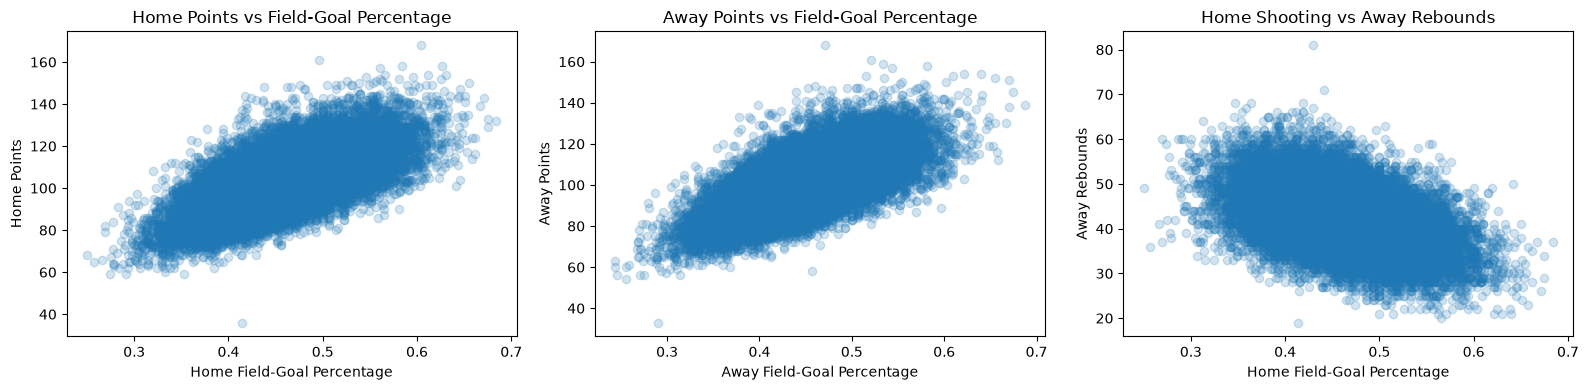

In [14]:
figure, axes = plt.subplots(1, 3, figsize=(16, 4))

# Home-team scoring and shooting efficiency
axes[0].scatter(
    games_df["FG_PCT_home"],
    games_df["PTS_home"],
    alpha=0.2
)
axes[0].set_title("Home Points vs Field-Goal Percentage")
axes[0].set_xlabel("Home Field-Goal Percentage")
axes[0].set_ylabel("Home Points")

# Away-team scoring and shooting efficiency
axes[1].scatter(
    games_df["FG_PCT_away"],
    games_df["PTS_away"],
    alpha=0.2
)
axes[1].set_title("Away Points vs Field-Goal Percentage")
axes[1].set_xlabel("Away Field-Goal Percentage")
axes[1].set_ylabel("Away Points")

# Home shooting efficiency and opposing rebounds
axes[2].scatter(
    games_df["FG_PCT_home"],
    games_df["REB_away"],
    alpha=0.2
)
axes[2].set_title("Home Shooting vs Away Rebounds")
axes[2].set_xlabel("Home Field-Goal Percentage")
axes[2].set_ylabel("Away Rebounds")

plt.tight_layout()
plt.show()

#### Scatter-Plot Findings

The first two scatter plots show clear positive relationships between field-goal percentage and points scored for both home and away teams.

As shooting efficiency increases, teams generally score more points. The pattern appears approximately linear, which is consistent with the similar Pearson and Spearman correlation coefficients.

The third scatter plot shows a negative relationship between the home team's field-goal percentage and the away team's rebounds.

When the home team shoots more accurately, fewer missed shots are available for the away team to rebound. The points are widely dispersed, so shooting percentage is not the only factor affecting rebounds.

A small number of extreme observations are visible in all three plots, but the overall relationship patterns remain clear.

### 6.2 Categorical–Categorical and Mixed Relationships

This section examines relationships involving categorical variables.

First, a cross-tabulation is used to compare game outcomes across seasons. Then, the home team's field-goal percentage is divided into four equal-frequency categories to examine its relationship with the game outcome.

In [15]:
# Frequency table: season and game outcome
season_win_counts = pd.crosstab(
    games_df["SEASON"],
    games_df["HOME_TEAM_WINS"]
).rename(
    columns={
        0: "Away-Team Wins",
        1: "Home-Team Wins"
    }
)

season_win_percentages = (
    pd.crosstab(
        games_df["SEASON"],
        games_df["HOME_TEAM_WINS"],
        normalize="index"
    ) * 100
).round(2).rename(
    columns={
        0: "Away-Team Win (%)",
        1: "Home-Team Win (%)"
    }
)

print("GAME OUTCOME COUNTS BY SEASON")
display(season_win_counts)

print("GAME OUTCOME PERCENTAGES BY SEASON")
display(season_win_percentages)

# Bin home field-goal percentage into four equal-frequency groups
home_fg_pct_bins = pd.qcut(
    games_df["FG_PCT_home"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

home_fg_win_crosstab = (
    pd.crosstab(
        home_fg_pct_bins,
        games_df["HOME_TEAM_WINS"],
        normalize="index"
    ) * 100
).round(2).rename(
    columns={
        0: "Away-Team Win (%)",
        1: "Home-Team Win (%)"
    }
)

print("GAME OUTCOME BY HOME FIELD-GOAL PERCENTAGE GROUP")
display(home_fg_win_crosstab)

GAME OUTCOME COUNTS BY SEASON


HOME_TEAM_WINS,Away-Team Wins,Home-Team Wins
SEASON,,
2003,585,800
2004,538,824
2005,566,866
2006,580,839
2007,549,862
2008,568,857
2009,567,857
2010,551,871
2011,448,656


GAME OUTCOME PERCENTAGES BY SEASON


HOME_TEAM_WINS,Away-Team Win (%),Home-Team Win (%)
SEASON,,
2003,42.24,57.76
2004,39.50,60.50
2005,39.53,60.47
2006,40.87,59.13
2007,38.91,61.09
2008,39.86,60.14
2009,39.82,60.18
2010,38.75,61.25
2011,40.58,59.42


GAME OUTCOME BY HOME FIELD-GOAL PERCENTAGE GROUP


HOME_TEAM_WINS,Away-Team Win (%),Home-Team Win (%)
FG_PCT_home,,
Low,69.61,30.39
Medium-Low,48.09,51.91
Medium-High,31.15,68.85
High,13.20,86.80


#### Categorical and Mixed-Variable Findings

The frequency table presents the number of home-team and away-team wins in each season, while the normalized table allows the win percentages to be compared across seasons.

The percentage of games won by the home team varies across seasons.

Home-team win rates range from 53.67% in the 2019 season to 61.41% in the 2012 season. In every season shown, the home team won more than half of the games, but the size of the apparent home advantage was not constant over time.

The field-goal percentage groups show a clear ordered relationship with the game outcome:

- In the low field-goal percentage group, the home team won 30.29% of the games.
- In the medium-low group, the home team won 51.91%.
- In the medium-high group, the home team won 68.85%.
- In the high group, the home team won 86.80%.

The home-team win percentage increases consistently across the four shooting-efficiency groups. This indicates a strong association between the home team's field-goal percentage and winning.

However, field-goal percentage is measured during the same game as the outcome. Therefore, it describes game performance but would not be available for a pre-game prediction. Using it for that purpose would introduce data leakage.

The binning simplifies the numerical variable and makes the relationship easier to interpret, but it also hides differences between observations within each group.

These findings describe associations in the dataset and do not prove that shooting percentage alone causes the game outcome.

### 6.3 Visual Analysis

The scatter plots were presented in Section 6.1.

The following visualizations summarize numerical distributions, game outcomes, and differences between home-team and away-team performance.

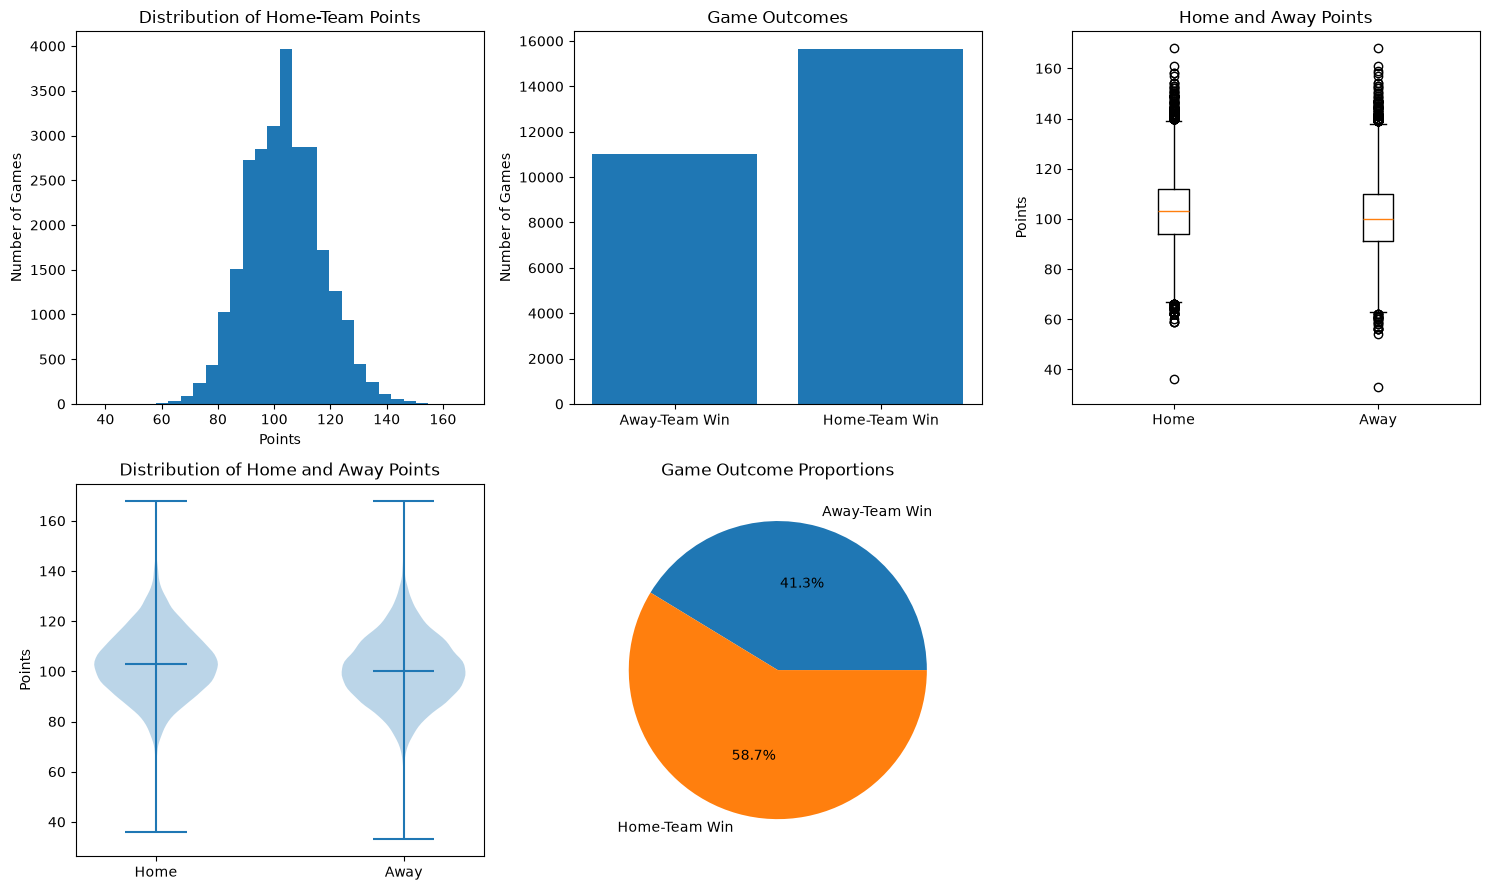

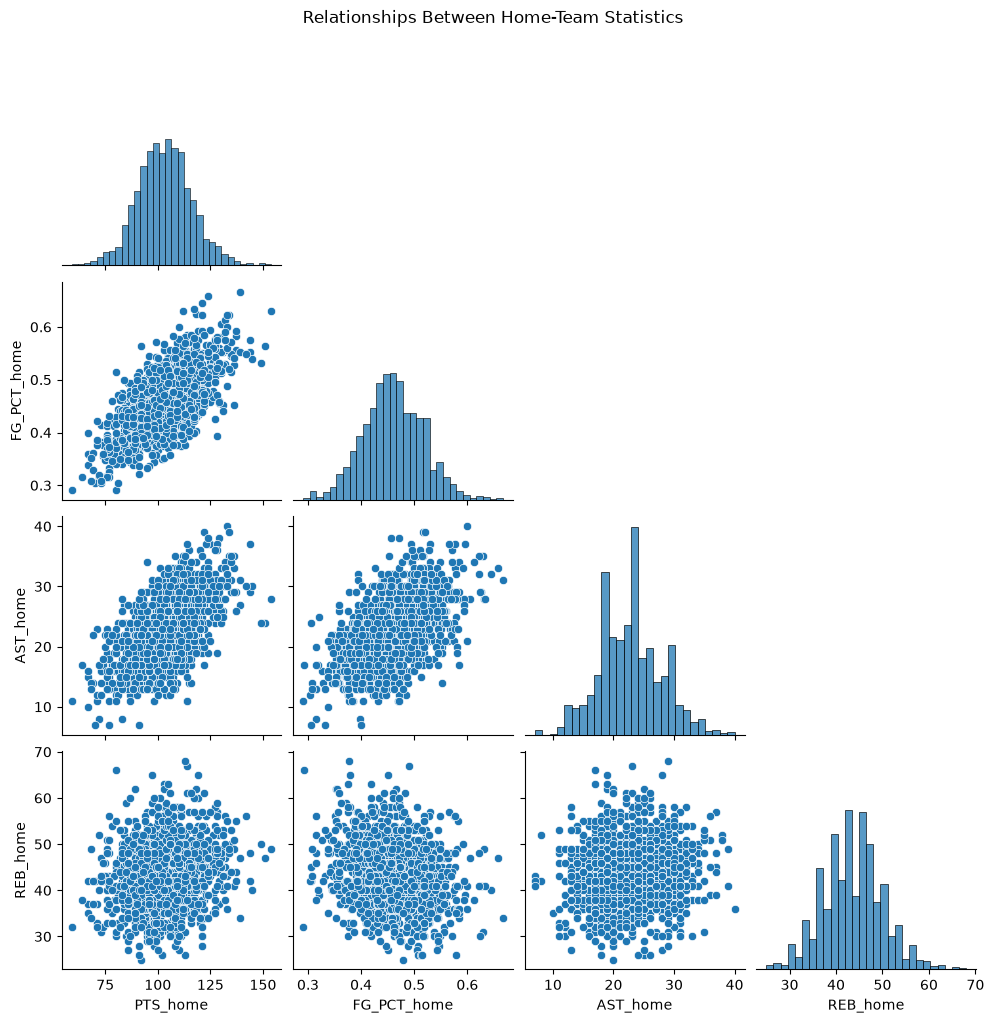

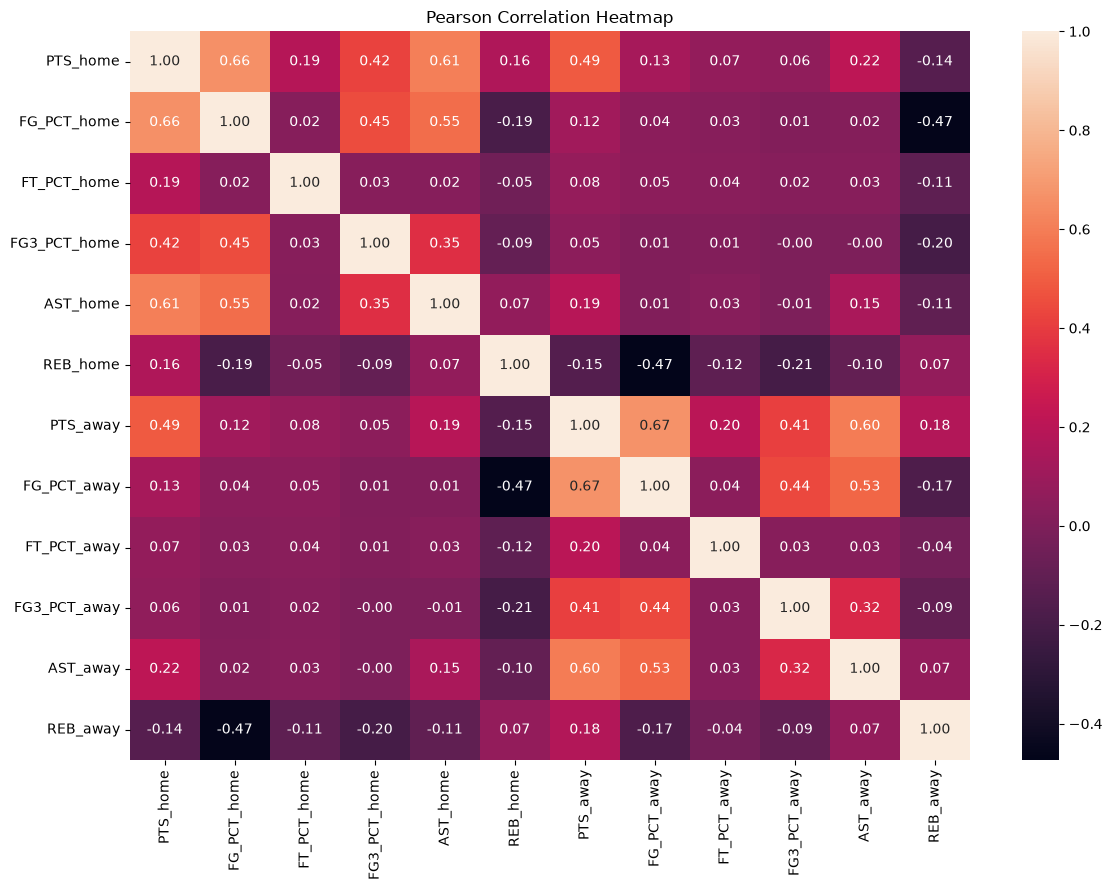

In [16]:
# Prepare game-outcome counts
win_counts = (
    games_df["HOME_TEAM_WINS"]
    .value_counts()
    .sort_index()
)

# Histogram, bar chart, boxplot, violin plot, and pie chart
figure, axes = plt.subplots(2, 3, figsize=(15, 9))

# Histogram
axes[0, 0].hist(
    games_df["PTS_home"].dropna(),
    bins=30
)
axes[0, 0].set_title("Distribution of Home-Team Points")
axes[0, 0].set_xlabel("Points")
axes[0, 0].set_ylabel("Number of Games")

# Bar chart
axes[0, 1].bar(
    ["Away-Team Win", "Home-Team Win"],
    win_counts.values
)
axes[0, 1].set_title("Game Outcomes")
axes[0, 1].set_ylabel("Number of Games")

# Boxplot
axes[0, 2].boxplot(
    [
        games_df["PTS_home"].dropna(),
        games_df["PTS_away"].dropna()
    ],
    tick_labels=["Home", "Away"]
)
axes[0, 2].set_title("Home and Away Points")
axes[0, 2].set_ylabel("Points")

# Violin plot
axes[1, 0].violinplot(
    [
        games_df["PTS_home"].dropna(),
        games_df["PTS_away"].dropna()
    ],
    showmedians=True
)
axes[1, 0].set_xticks([1, 2])
axes[1, 0].set_xticklabels(["Home", "Away"])
axes[1, 0].set_title("Distribution of Home and Away Points")
axes[1, 0].set_ylabel("Points")

# Pie chart
axes[1, 1].pie(
    win_counts.values,
    labels=["Away-Team Win", "Home-Team Win"],
    autopct="%1.1f%%"
)
axes[1, 1].set_title("Game Outcome Proportions")

# Remove the unused subplot
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()


# Pairplot using a sample to keep the visualization readable
pairplot_columns = [
    "PTS_home",
    "FG_PCT_home",
    "AST_home",
    "REB_home"
]

pairplot_data = games_df[
    pairplot_columns
].dropna()

pairplot_sample_df = pairplot_data.sample(
    n=min(1500, len(pairplot_data)),
    random_state=42
)

sns.pairplot(
    pairplot_sample_df,
    corner=True,
    diag_kind="hist"
)

plt.suptitle(
    "Relationships Between Home-Team Statistics",
    y=1.02
)
plt.show()


# Pearson correlation heatmap
correlation_matrix = (
    games_df[numeric_game_columns]
    .corr(method="pearson")
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Pearson Correlation Heatmap")
plt.tight_layout()
plt.show()

#### Visual Findings

The histogram shows that home-team points are concentrated around approximately 100 points. The distribution is roughly symmetric, with a small number of unusually low and high scores.

The bar chart and pie chart show that home teams won 58.7% of the games, compared with 41.3% for visiting teams.

The boxplot shows that the median number of points is slightly higher for home teams. Both home-team and away-team point distributions contain low and high statistical outliers.

The violin plot shows that the home-team and away-team point distributions have similar shapes, although the home-team distribution is centered slightly higher.

The pairplot shows positive relationships between home-team points, field-goal percentage, and assists. The relationship between points and rebounds appears weaker.

The heatmap confirms that the strongest positive numerical relationships involve points, field-goal percentage, and assists for the same team. It also highlights negative relationships between one team's shooting percentage and the opposing team's rebounds.

Free-throw percentage has relatively weak relationships with most other game statistics.

Together, the visualizations support the earlier descriptive and correlation findings. However, the observed relationships do not by themselves establish causation.

## 7. Index Analysis

This section examines the current DataFrame index, the uniqueness of the game identifier, the chronological order of the records, and changes in selected statistics across seasons.

In [17]:
# Convert the game-date column to datetime
games_df["GAME_DATE_EST"] = pd.to_datetime(
    games_df["GAME_DATE_EST"],
    errors="coerce"
)

print("INDEX PROPERTIES")
print("-" * 50)
print(f"Index type: {type(games_df.index).__name__}")
print(f"Index is unique: {games_df.index.is_unique}")
print(f"Index is time-based: {isinstance(games_df.index, pd.DatetimeIndex)}")
print(f"Index is sorted: {games_df.index.is_monotonic_increasing}")

print("\nGAME IDENTIFIER")
print("-" * 50)
print(f"GAME_ID is unique: {games_df['GAME_ID'].is_unique}")
print(f"Duplicated GAME_ID values: {games_df['GAME_ID'].duplicated().sum()}")

print("\nDATE PROPERTIES")
print("-" * 50)
print(f"Missing or invalid dates: {games_df['GAME_DATE_EST'].isna().sum()}")
print(f"Earliest date: {games_df['GAME_DATE_EST'].min().date()}")
print(f"Latest date: {games_df['GAME_DATE_EST'].max().date()}")
print(
    f"Rows are chronologically sorted: "
    f"{games_df['GAME_DATE_EST'].is_monotonic_increasing}"
)

season_trends_df = games_df.groupby("SEASON").agg(
    Games=("GAME_ID", "count"),
    Home_Win_Percentage=("HOME_TEAM_WINS", "mean"),
    Average_Home_Points=("PTS_home", "mean"),
    Average_Away_Points=("PTS_away", "mean")
)

season_trends_df["Home_Win_Percentage"] *= 100

display(season_trends_df.round(2))

INDEX PROPERTIES
--------------------------------------------------
Index type: RangeIndex
Index is unique: True
Index is time-based: False
Index is sorted: True

GAME IDENTIFIER
--------------------------------------------------
GAME_ID is unique: False
Duplicated GAME_ID values: 29

DATE PROPERTIES
--------------------------------------------------
Missing or invalid dates: 0
Earliest date: 2003-10-05
Latest date: 2022-12-22
Rows are chronologically sorted: False


,Games,Home_Win_Percentage,Average_Home_Points,Average_Away_Points
SEASON,,,,
2003,1385,57.76,94.91,91.09
2004,1362,60.50,98.60,95.38
2005,1432,60.47,98.41,95.17
2006,1419,59.13,99.85,96.94
2007,1411,61.09,101.27,97.55
2008,1425,60.14,100.92,97.90
2009,1424,60.18,101.65,98.75
2010,1422,61.25,100.76,97.38
2011,1104,59.42,97.39,94.43


#### Index and Time Findings

The DataFrame uses a default `RangeIndex`.

This index is unique and sorted in increasing order, but it is not time-based and does not carry analytical meaning. Its order only reflects the current row positions in the DataFrame.

`GAME_ID` cannot be used directly as a unique index because 29 game identifiers appear more than once.

The `GAME_DATE_EST` column was successfully converted to a datetime variable, with no invalid or missing dates. The dataset covers the period from October 5, 2003, to December 22, 2022.

The rows are not sorted chronologically by game date. Therefore, the current row order should not be interpreted as a time sequence. A time-based analysis would require sorting the data by `GAME_DATE_EST` or temporarily using it as a time index.

The seasonal summary shows that the main descriptive statistics change over time.

Average scoring increased substantially across the covered period. Average home-team points increased from 94.91 in the 2003 season to 114.28 in 2022, while average away-team points increased from 91.09 to 111.24.

The home-team win percentage also varies across seasons. It reached 61.41% in 2012 and fell to 53.67% in 2019, showing that the apparent home advantage is not constant over time.

The number of records differs between seasons. For example, the 2022 season contains only 542 records, much fewer than most other seasons. Therefore, comparisons between seasons should be interpreted cautiously because some seasons may have incomplete or shorter coverage.

The original index is retained because changing it is not necessary for the current analysis. Chronological sorting can be performed when required without modifying the raw dataset permanently.

## 8. Data Insights and Story

**Main Insight 1 — Home-Team Advantage**

Home teams won 58.7% of the games in the dataset, compared with 41.3% for visiting teams.

However, the size of the home-team advantage changes across seasons. The home-team win percentage ranges from 53.67% in 2019 to 61.41% in 2012. Therefore, home advantage appears to exist in the dataset, but it is not constant over time.

**Main Insight 2 — Shooting Efficiency and Game Performance**

Field-goal percentage has a strong positive relationship with points scored.

The Pearson correlations between points and field-goal percentage are 0.662 for home teams and 0.669 for away teams.

The binned analysis also shows a clear relationship between home-team shooting efficiency and winning. Home teams in the lowest field-goal percentage group won 30.29% of their games, while teams in the highest group won 86.80%.

This makes field-goal percentage highly informative for explaining game outcomes. However, it is measured during the game and would cause data leakage if used to predict the result before the game begins.

**Main Insight 3 — Scoring Increased Over Time**

Average team scoring increased substantially across the period covered by the dataset.

Average home-team points increased from 94.91 in the 2003 season to 114.28 in 2022. Average away-team points increased from 91.09 to 111.24 over the same period.

This indicates that statistics calculated across all seasons may hide important temporal changes in NBA scoring patterns.

**Biases and Risks**

The dataset does not include important contextual information such as player injuries, player availability, rest days, travel distance, coaching changes, or game importance.

In addition, 99 records from the beginning of the 2003 season are missing all 12 team-statistic values. The structured missingness may introduce historical bias if these records differ systematically from the rest of the dataset.

The dataset also contains 29 duplicated game identifiers. Most duplicated records are nearly identical, but two contain meaningful conflicting values.

The 2022 season contains only 542 records, which suggests incomplete coverage compared with most other seasons.

**Possible Engineering and Statistical Failure Points**

Several mistakes could lead to incorrect conclusions or unreliable models:

- Treating team and game identifiers as continuous numerical variables.
- Using same-game statistics for pre-game prediction, which would introduce data leakage.
- Removing statistical outliers automatically, even though unusual NBA games may be valid observations.
- Ignoring duplicated game identifiers and conflicting records.
- Comparing seasons without considering incomplete or unequal seasonal coverage.
- Assuming that correlations prove causal relationships.
- Ignoring changes in scoring and home-team advantage over time.

**What Was Learned**

The analysis showed that the dataset is not simply a collection of correct and complete game records. It reflects a collection process with missing information, duplicate identifiers, incomplete contextual variables, and changes across time.

A notable finding is that home-team advantage exists overall but varies considerably between seasons. The analysis also showed that unusual statistical values should not automatically be treated as errors, because extreme performances are a natural part of professional basketball.

The results demonstrate that understanding data quality, measurement limitations, and temporal structure is necessary before using the dataset for statistical modeling or decision-making.